# Natural Language Processing - Summer Term 2026
##### Hochschule Karlsruhe
##### Prof. Dr. Jannik Strötgen
##### Thanks to J.-Prof. Dr. Andreas Spitz, Rita Sevastjanova, Yannick Metz (University of Konstanz) and my former teaching asssistant Paul Löhr

# Exercise 01

### You will learn

- how to get the infrastructure up and running
- how you will complete the exercises


- about some different data formats
- how to write a simple data parser
- analyze text occurrences.

ATTENTION: Please be aware that this ex01 mentions python 3.9 - you have 3.14 installed. It might be that you need to modify the requirements.txt accordingly, but all other things should hopefully work fine.

## Task 0.1 - Introduction (0 P):

- learn about global and local environments
- create a new local environment and add it to jupyter notebook
- installed the dependencies in requirements.txt for each exercise
- start jupyter notebook or jupyter-lab, switch the kernel to your environment and start solving


This assumes:
- you already have Python 3.9 installed
- you have Jupyter Notebook or Jupyterlab installed
- Python and Jupyter Notebook are already included in Anaconda, which we recommend due to the ease of installation. You can, however, also install them manually.


### Decide between local environment and global installation

When Python is installed, it is installed globally, meaning that all users and applications use the same version and, more importantly, the same version of packages (libraries). As we might have some applications that run only with a specific version of a library, it is hard and sometimes impossible to resolve version conflicts system-wide.

Therefore it is possible to create *environments*, of which you can think of as encapsulated copies of the python interpreter and a set of specific versions of packages (the idea of containerization before and during the earliest years of docker). It is customary to specify the versions in a file called `requirements.txt`, which lists the package name `wordcloud`.

**We strongly recommend creating environments to avoid global version conflicts.**

That said, nothing prevents you in principle to just install the required packages in the global namespace. We will use the latest version of packages (as listed on https://pypi.org/) and are unlikely to encounter version conflicts. We will not deduce points for using a global installation per se, but note that when version conflicts occur, this falls within your responsibility.

### Create an environment and make it usable in Jupyter Notebook

Using your global installation, start a terminal in the top folder where you store your exercises. Then execute the following commands in a shell:

```
# creates the environment in the folder .env
python -m venv .env            

# activate the environment
source .env/bin/activate   # for linux only
.env\Scripts\activate.bat      # for windows only

# add the jupyter kernel to the environment
pip install ipykernel

# add your environment to jupyter notebook
python -m ipykernel install --name=.env
```

### What you have now

You now have:

 - a new environment called .env in your top exercise folder
 - added the environment to the (global) jupyter notebook settings
 
 
You now can:
 
 - **configure your local environment** as you like, for example, install specific packages (**for each exercise**)
 - **start jupyter notebook globally** and change the kernel to use your local environment via Kernel->Change Kernel>.env in the top menu bar. **Then you can start to solve your exercise.**

While it would be maybe more intuitive to execute jupyter notebook *within* the environment, this is the least cumbersome way..

### Configure your environment
##### Install requirements within the environment
by typing the following command in a terminal in this directory

`source .env/bin/activate`   # windows: `.env\Scripts\activate.bat`

`pip install -r requirements.txt`  # distributed with the latest exercise

*This is also necessary when the dependencies have changed!*

### Start Jupyter Notebook (Jupyterlab) within this environment

Close this window, close the previous terminal session and type

`jupyter notebook` or `jupyter-lab`

in a new terminal.

- *Select your current exercise ipynb file*
- *Change the kernel* to use your .env via Kernel->Change Kernel>.env 

*This is required every time to start up your exercise when coding.*

## Task 0.2 - How to solve the exercises (0 P):

The upcoming exercises contain both code submission as well as written answers.

### Code-Submission

For these assignments, you complete the template code that we already provide you within this notebook. For example an exercise might look like this:

In [1]:
def square(x):
    # Assignment XY: calculate the square here and return the value
    pass

Then you are expected to complete the missing functionality. In this case, the function might look like this:

In [2]:
def square(x):
    return x*x

And to check, we can even call the function and get a result:

In [3]:
square(4)

16

### Structure your code within external python files

While you can solve all coding directly within the jupyter notebook, it is also possible to include external python files from the containing directory.

For this to work, you have to enable live edit capabilities by executing the following commands in your jupyter notebook:
```
%load_ext autoreload
%autoreload 
```
Then you can include files like `util.py` by just importing them with `import util`.

**In principle, we recommend completing all your exercises within the notebook wherever possible and only include external files when strictly necessary!**

**Beware:** *If you include any extern files, please always ensure that you submit your solutions as an archive, which includes both the ipynb file and all the referenced files! Otherwise, we ***cannot*** grade them.* (this holds if you are the one to present the solution in the tutorial session and are responsible for sharing your code as a sample solution)

### Text-Submissions
Another type of submissions is a text submission. Here you are asked for a written answer.

*Tip*: You can use Markdown formatting if you set the cell type in the top menu bar to `Markdown`!

**To edit a cell, you can double-click it.**

For example, in the following case:

*Question*: What is Python?

\# ANSWER HERE (Double click to edit)

we expect you to write your answer in this cell (or several, if you chose to do so), like this:

Python is an interpreted, high-level, general-purpose programming language and commonly used in data science.

#### Markdown Support
Please use the markdown syntax to make your submission more readable!

Here are some examples:

##### Headings

*italic*

**bold**

\*literal asterisks\*

Latex code: $e^{i\pi} + 1 = 0$


Nice python styles (not for code submission!!)
```python
print "Hello World!"
```

tables

| This | is   |
|------|------|
|   a  | table|

### Include Images
If you need to include external images (not any visualizations computed inside this notebook), you can reference the file like this:


![my image 123](cat.jpg)


**Beware:** *If you include any extern files, please always ensure that you submit your solutions as an archive, which includes both the ipynb file and all the referenced files! Otherwise, we **cannot** grade them. (this holds if you are the one to present the solution in the tutorial session and are responsible for sharing your code as a sample solution)

This concludes the short precursor, and we can start with the real exercises.

---

## Task 1 - Data Description (10P):

We provided some data files together with this assignment. These data files have a specific structure with some meta-information. Study the files and try to understand what they contain. Then try to make some sense out of this information.
Prepare a short description of the data in written form naming interesting facts (e.g., what kind of data are you seeing, how is it encoded).

Hint: It might help to read the text a little to understand what the data is all about.

### Datenset 1: Debates

**Content:** The dataset contains transcripts of the 2016 U.S. presidential debates between Hillary Clinton and Donald Trump.

**Format:** XML

**Encoding/ Structure:** The data is organized into many utterances that contain the spoken text and metadata such as speaker name, sprecherId, timestamp or id. Furthermore, the files use UTF-8 encoding, which tells programs how the text is stored so that special characters can be read correctly.

**Notable Characteristics:**

- The Files are easy to read, also for humans, because the speech is stored directly in the XML elements
- The schema is not fully consistent across all files, because the later files contain additional metadata attributes such as timestamp and id, while the first file contains fewer attributes.
### Datenset 2: Reddit

**Content:** The dataset contains a Reddit discussion thread about the first 2016 U.S. presidential debate, including the original post and many user comments and replies.

**Format:** JSON

**Encoding/ Structure:** The data is organized into one main post and many comments, including replies to other comments. This creates a nested structure.

**Notable Characteristics:**

- The data includes a lot of metadata such as author, subreddit, IDs, timestamps and so on.
- The dataset is still fairly human-readable and the textual content can be found in fields such as title, selftext, and body.
### Datenset 3: TV

**Content:** The dataset contains a collection of debate excerpts from different TV broadcasts and channels.

**Format:** CSV

**Encoding/ Structure:** Each row represents one broadcast segment and usually contains a short transcript excerpt together with metadata such as channel, network, program, timestamps duration etc..

**Notable Characteristics:**

- The text is still fairly human-readable because the transcript snippets are stored directly in a text field, but the fragmented structure makes the full debate harder to follow.
- The dataset is less clean and less uniform than the XML files, because some rows contain only short snippets or less informative text.
- The dataset combines transcript snippets with broadcast metadata, which makes it useful for comparing how debate content appeared on different TV programs.

## Task 2 - Data Parser Implementation (10 P):

Use the provided framework that you have now in your project. Write a reader to read in the data files and the appropriate data structures that you need in the beginning. You may only need to store things in your data structure that you will need later (e.g., lots of attributes in the reddit dump are useless for us).

Follow the instructions in the following code snippets.

In [4]:
# import the necessary library functions we prepared
from utils import create_word_cloud

In [5]:
import wordcloud
from xml.etree import ElementTree as ET
import json
import csv
import pandas as pd
import re

In [6]:
#
# Part 1
#
#  - Read all the files in the data directory (and subdirectories)
#
# You may use any available library here, but please add it to the requirements.txt and SUBMIT the changed file
# Create python classes to represent your data. For the beginning, the simple text body should be sufficient.
# However, if you want to add other metadata you are free to do so.
# Regard each folder as one dataset. So bin Part 3, you should generate three individual word clouds.
# 
# Hint: You do _not_ need to represent the thread structure of the reddit data with your Python class instances.
# 
# Example:
#loremipsum = read_lorem_ipsum_text()
    
# TODO - ADD YOUR OTHER READER HERE


from importlib.resources import path
import glob

file_path_x = glob.glob(f"data/debates/*.xml")
file_path_j = "data/reddit/redditdump.json"
file_path_c = glob.glob(f"data/tv/*.csv")

def xml_parsing ():
        data = ""
        for file_path in file_path_x:
                f = open(file_path, 'r', encoding='utf-8')
                tree = ET.parse(f)
                root = tree.getroot()
                value = root.findall('topic/utterance')
                texte = []
                for element in value:
                        texte.append(element.text)
                        data = " ".join(texte)
        return data
         

def json_parsing():
        texte_json = []
        with open(file_path_j, "r", encoding='utf-8') as f:
                data = json.load(f)

        for item in data:
                children = item.get('data', {}).get('children', {})
                for child in children:
                        kind = child.get('kind')
                        child_data = child.get('data',{})
                        if kind == 't3':
                                text = child_data.get('selftext')
                                if text:
                                        texte_json.append(text)
                                 
                        elif kind == 't1':
                                content = child_data.get('body')
                                if content:
                                        texte_json.append(content)
        all = " ".join(texte_json)
        redu_first = re.sub(r'https?:[^\s]+', '' , all)
        redu_second = re.sub(r'\n', '', redu_first)
        redu_third = re.sub(r'[**]', '', redu_second)
        final = re.sub(r'\\', '', redu_third)
        return final


def csv_parsing():
        transcript = ""
        for file_path in file_path_c:
                f = open(file_path, "r", encoding='utf-8')
                df = pd.read_csv(f, usecols=["transcript"])
                transcript += " ".join(df["transcript"].dropna())
        return transcript

In [7]:
json_parsing()

'The first Presidential Debate for the 2016 Elections will air tonight at 9:00PM Eastern at Hofstra University in New York. The debate will feature Donald Trump and Hillary Clinton in their first head-to-head televised debate. The debate will be 90 minutes and commercial free.The Debate is hosted by the Commission on Presidential Debates and will be moderated by NBC’s Lester Holt. Hillary Clinton will [receive the first question](-----Where to Watch-Unlike the primaries, these debates are hosted by the Commission on Presidential Debates and the broadcast is not restricted to one network, making for a wide range of viewing options. Here are just a few of the ways you can watch:Television:The event will be broadcast on most major TV channels, including ABC, CBS, CNN, C-SPAN, Fox News, MSNBC, and Univision.Live Streams:[C-SPAN]([Washington Post (YouTube)]([PBS (YouTube)]([NBC (YouTube)]([Bloomberg Politics (Twitter with real-time fact checking)]([ABC (Facebook)](------Live Discussion-If y

In [8]:
csv_parsing()

'>> NO, I DIDN\'T SAY THAT AT ALL. I DON\'T THINK YOU UNDERSTOOD WHAT WAS SAID. THIS WAS LOCKER ROOM TALK. I\'M NOT PROUD OF IT. I APOLOGIZED TO MY FAMILY, I THAT? >> FRANKLY, YOU HEAR THESE THINGS. THEY ARE SAID. I WAS EMBARRASSED BY IT. ON POLITICS, POLICIES, PRINCIPLE, BUT I NEVER WHAT HE DOES TO WOMEN. AND HE HAS SAID THAT THE VIDEO DOESN\'T REPRESENT WHO HE IS. BUT I THINK IT\'S CLEAR TO ANYONE WHO HEARD IT THAT IT REPRESENTS EXACTLY WHO HE IS. >> MR. FRUMP -- I WANT TO GET TO AUDIENCE QUESTIONS ONLINE QUESTIONS. >> SO, SHE\'S ALLOWED TO DO THAT HAPPENED. IF YOU LOOK AT BILL CLINTON, FAR WORSE, MINOR WORDS AND HIS WAS ACTION. HIS WAS WHAT HE\'S DONE TO WOMEN, COUNTRY. THAT\'S HIS CHOICE. WHEN I HEAR SOMETHING LIKE THAT, I AM REMINDED OF WHAT MY FRIEND, COUNTRY. THAT\'S HIS CHOICE. WHEN I HEAR SOMETHING LIKE THAT, I AM REMINDED OF WHAT MY FRIEND, I WAS SO SURPRISED SEE HIM SIGN ON WITH THE DEVIL. BUT WHEN YOU TALK ABOUT APOLOGY, I THINK THE ONE THAT SHOULD YOU REALLY BE APOLOGIZING

In [9]:
xml_parsing()

' Good evening from Hofstra University in Hempstead, New York. I am Lester Holt, anchor of "NBC Nightly News.” I want to welcome you to the first presidential debate.\nThe participants tonight are Donald Trump and Hillary Clinton. This debate is sponsored by the Commission on Presidential Debates, a nonpartisan, nonprofit organization. The commission drafted tonight\'s format, and the rules have been agreed to by the campaigns.\nThe 90-minute debate is divided into six segments, each 15 minutes long. We\'ll explore three topic areas tonight: Achieving prosperity; America\'s direction; and securing America. At the start of each segment, I will ask the same lead-off question to both candidates, and they will each have up to two minutes to respond. From that point until the end of the segment, we\'ll have an open discussion.\nThe questions are mine and have not been shared with the commission or the campaigns. The audience here in the room has agreed to remain silent so that we can focus 

In [10]:
xml_data = xml_parsing()
json_data = json_parsing()
csv_data = csv_parsing()


In [11]:
# 
# Part 2
#
#  - Count the words in a map. Do so for each dataset.
#
# Example:
#word_count_lorem = {}
#words = loremipsum.split(" ")
#for word in words:
    #word_count_lorem[word] = word_count_lorem.get(word, 0) + 1

# TODO - ADD YOUR OTHER COUNTER FUNCTIONS HERE

word_count_xml = {}
words = xml_data.split()

for word in words:
        word_count_xml[word] = word_count_xml.get(word, 0) + 1

print(word_count_xml)



{'Good': 3, 'evening': 2, 'from': 41, 'Hofstra': 3, 'University': 5, 'in': 219, 'Hempstead,': 1, 'New': 15, 'York.': 2, 'I': 434, 'am': 47, 'Lester': 2, 'Holt,': 1, 'anchor': 1, 'of': 338, '"NBC': 1, 'Nightly': 1, 'News.”': 1, 'want': 48, 'to': 571, 'welcome': 2, 'you': 258, 'the': 596, 'first': 17, 'presidential': 7, 'debate.': 3, 'The': 46, 'participants': 1, 'tonight': 2, 'are': 217, 'Donald': 23, 'Trump': 7, 'and': 315, 'Hillary': 9, 'Clinton.': 6, 'This': 6, 'debate': 7, 'is': 285, 'sponsored': 1, 'by': 50, 'Commission': 1, 'on': 90, 'Presidential': 1, 'Debates,': 1, 'a': 316, 'nonpartisan,': 1, 'nonprofit': 1, 'organization.': 1, 'commission': 2, 'drafted': 1, "tonight's": 1, 'format,': 1, 'rules': 1, 'have': 252, 'been': 56, 'agreed': 2, 'campaigns.': 2, '90-minute': 1, 'divided': 1, 'into': 31, 'six': 3, 'segments,': 1, 'each': 4, '15': 4, 'minutes': 10, 'long.': 2, "We'll": 3, 'explore': 1, 'three': 2, 'topic': 1, 'areas': 1, 'tonight:': 1, 'Achieving': 1, 'prosperity;': 1, "A

In [12]:
word_count_json = {}
words_j = json_data.split()

for word in words_j:
        word_count_json[word] = word_count_json.get(word, 0) + 1

print(word_count_json)


{'The': 5, 'first': 5, 'Presidential': 4, 'Debate': 4, 'for': 23, 'the': 100, '2016': 1, 'Elections': 1, 'will': 27, 'air': 1, 'tonight': 3, 'at': 11, '9:00PM': 1, 'Eastern': 1, 'Hofstra': 1, 'University': 1, 'in': 31, 'New': 1, 'York.': 1, 'debate': 10, 'feature': 1, 'Donald': 7, 'Trump': 23, 'and': 56, 'Hillary': 9, 'Clinton': 8, 'their': 5, 'head-to-head': 1, 'televised': 1, 'debate.': 4, 'be': 20, '90': 2, 'minutes': 2, 'commercial': 1, 'free.The': 1, 'is': 29, 'hosted': 2, 'by': 9, 'Commission': 2, 'on': 19, 'Debates': 2, 'moderated': 1, 'NBC’s': 1, 'Lester': 1, 'Holt.': 1, '[receive': 1, 'question](-----Where': 1, 'to': 63, 'Watch-Unlike': 1, 'primaries,': 1, 'these': 2, 'debates': 3, 'are': 16, 'broadcast': 2, 'not': 18, 'restricted': 1, 'one': 4, 'network,': 1, 'making': 2, 'a': 49, 'wide': 1, 'range': 1, 'of': 32, 'viewing': 1, 'options.': 1, 'Here': 1, 'just': 12, 'few': 2, 'ways': 1, 'you': 11, 'can': 2, 'watch:Television:The': 1, 'event': 2, 'most': 2, 'major': 1, 'TV': 1, 

In [13]:


word_count_csv = {}
final = re.sub(r'>>', '', csv_data)

words_c = final.split(" ")

for word in words_c:
        word_count_csv[word] = word_count_csv.get(word, 0) + 1

print (word_count_csv)

{'': 7343, 'NO,': 539, 'I': 9690, "DIDN'T": 465, 'SAY': 913, 'THAT': 5457, 'AT': 1261, 'ALL.': 202, "DON'T": 993, 'THINK': 1382, 'YOU': 7102, 'UNDERSTOOD': 221, 'WHAT': 2290, 'WAS': 3396, 'SAID.': 421, 'THIS': 2206, 'LOCKER': 322, 'ROOM': 327, 'TALK.': 302, "I'M": 675, 'NOT': 1715, 'PROUD': 279, 'OF': 4977, 'IT.': 1423, 'APOLOGIZED': 127, 'TO': 9362, 'MY': 1560, 'FAMILY,': 133, 'THAT?': 380, 'FRANKLY,': 98, 'HEAR': 308, 'THESE': 305, 'THINGS.': 231, 'THEY': 1220, 'ARE': 1205, 'EMBARRASSED': 179, 'BY': 1005, 'ON': 1442, 'POLITICS,': 30, 'POLICIES,': 30, 'PRINCIPLE,': 30, 'BUT': 2095, 'NEVER': 531, 'HE': 3279, 'DOES': 454, 'WOMEN.': 877, 'AND': 6693, 'HAS': 1843, 'SAID': 1498, 'THE': 9502, 'VIDEO': 202, "DOESN'T": 827, 'REPRESENT': 230, 'WHO': 1035, 'IS.': 384, "IT'S": 1012, 'CLEAR': 55, 'ANYONE': 52, 'HEARD': 332, 'IT': 2872, 'REPRESENTS': 13, 'EXACTLY': 19, 'MR.': 586, 'FRUMP': 10, '--': 3451, 'WANT': 1148, 'GET': 724, 'AUDIENCE': 114, 'QUESTIONS': 66, 'ONLINE': 6, 'QUESTIONS.': 34, 'S

In [14]:
# 
# Part 3
#
#  - Create a word cloud for the dataset.
# 
# Example:


# TODO - CREATE THE OTHER THREE WORDCLOUDS HERE

### Wordcloud 1: Debates (xml)

Word Cloud for XML:


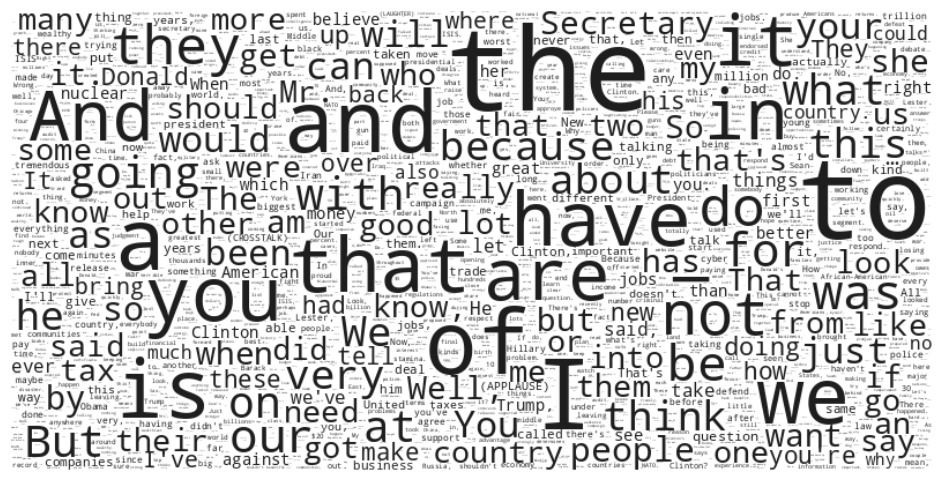

In [15]:
create_word_cloud(word_count_xml, "Word Cloud for XML")

### Wordcloud 2: Reddit (json)

Word Cloud for JSON:


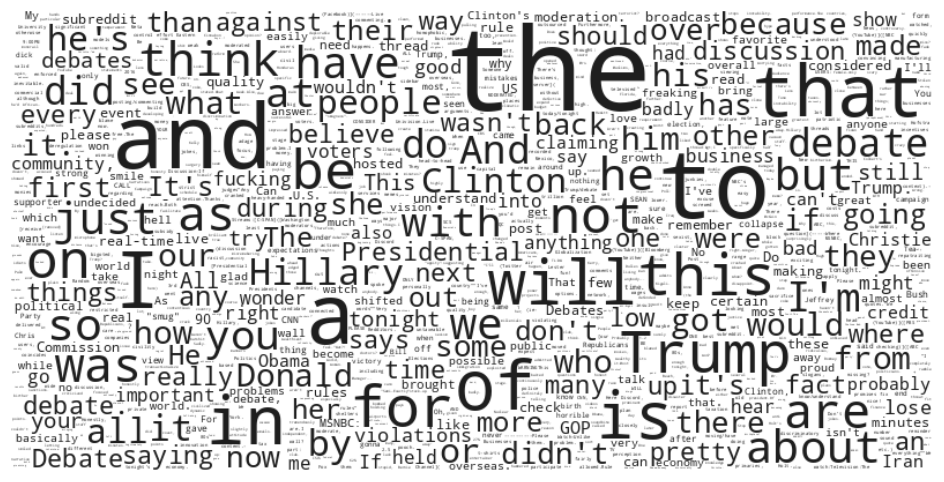

In [16]:
create_word_cloud(word_count_json, "Word Cloud for JSON")

### Wordcloud 3: TV (csv)

Word Cloud for CSV:


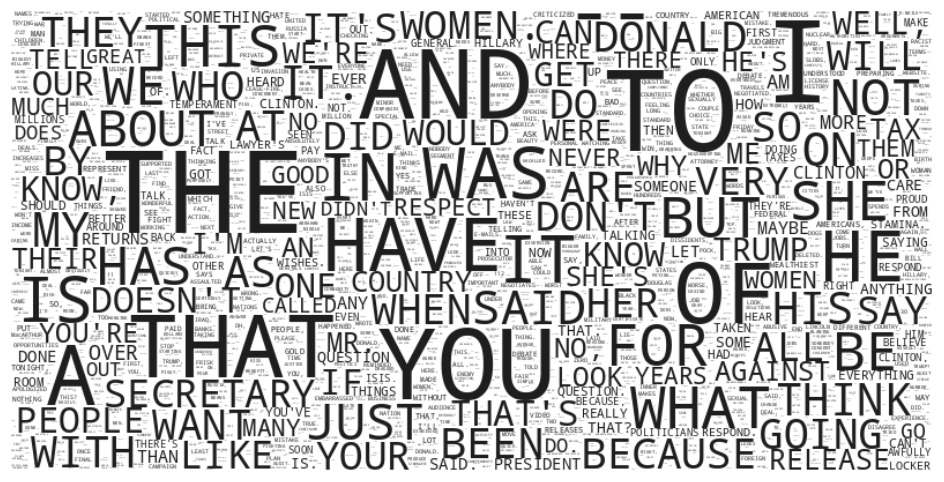

In [17]:
create_word_cloud(word_count_csv, "Word Cloud for CSV")

## Task 3 - Word-Cloud Interpretation and Next Steps (10 P):

Interpret the word clouds you created. Can you tell any differences from the different data sets? What do you think would be the next steps to improve the word clouds?

Reference the corresponding figure and write down your interpretation.

The word clouds can already give a first impression of the three datasets, but they should be interpreted carefully because no stopword filtering has been applied yet. This means that many very common and not very meaningful words appear often. A first simple improvement would therefore be to remove stopwords such as *the*, *a*, *and*, *is*, or *I*, as well as other frequent but uninformative words from this specific domain, for example candidate names or words like *said* and *think*. Another useful improvement would be to combine words that belong together, such as *tax returns* or *supreme court*, because these expressions carry more meaning as a phrase than as two separate words. In general, the clouds are useful for an overview, but they would become more informative after basic preprocessing.

The **debate XML** word cloud is likely the clearest and most focused of the three datasets. Since the XML files contain the original debate transcripts, the words mainly come from the direct exchange between the moderator and the candidates. Even without stopword removal, the vocabulary should be more formal and topic-centered than in the other datasets. We would expect politically relevant words such as *country*, *people*, *president*, or *jobs* to appear often. This makes sense because the debate transcripts represent the primary source material.

The **Reddit JSON** word cloud is likely more informal and conversational. Reddit comments are reactions written by users, so the language is more subjective and opinion-based. Without stopword filtering, the cloud will probably contain many filler words and frequent conversational expressions in addition to more meaningful terms. Compared with the debate transcripts, the Reddit data should therefore look less formal and more argumentative. It reflects how people discuss and evaluate the debate rather than the debate itself.

The **TV CSV** word cloud is different again because this dataset consists of many broadcast snippets from different channels and programs rather than one clean transcript. As a result, some words may appear very often simply because certain moments were repeated in news coverage. This can make the TV word cloud more influenced by media selection and repetition than by the full debate content itself. Words connected to memorable debate moments may therefore stand out more strongly. Overall, the TV cloud reflects not only what was said in the debates, but also what television coverage chose to emphasize.


---

#### Submitting your results: (this holds if you are the one to present the solution in the tutorial session and are responsible for sharing your code as a sample solution)

To submit your results, please:

- save this file, i.e. `ex01_assignment.ipynb` and update everything so that everything runs smoothly with Python 3.14.
- if you reference any external files (e.g., images), please create a zip or rar archive and put the notebook files and all referenced files in there.
- send me your "submission"

**Remarks:**
    
- Do not copy any code from the Internet. In case you want to use publicly available code, please, add the reference to the respective code snippet.
- Check your code compiles and executes, even after you have restarted the Kernel (Menu -> Kernel -> Restart & Run all).
- Submit your written solutions and the coding exercises within the provided spaces and not otherwise.
- Write the names of all group members in the top section.